# Load Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pygenelab as pgl

In [3]:
import scanpy as sc 
import numpy as np
import decoupler as dc
import pandas as pd

# Load Dataset

In [4]:
# load mice dataset
MICE_DATASET_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
adata_mice = sc.read_h5ad(MICE_DATASET_PATH)

In [5]:
# get female fast iix only
adata_mice_f_iix = pgl.subset_adata_by_obs(adata_mice,
                                           filters={"sex": "F",
                                                    "C_scANVI": ["Fast IIX"]})

# get female fast iib only
adata_mice_f_iib = pgl.subset_adata_by_obs(adata_mice,
                                           filters={"sex": "F",
                                                    "C_scANVI": ["Fast IIB"]})

# Load Geneset

In [6]:
# load geneset
MICE_ALL_PATHWAYS_PATH = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"
PATHWAY = "REACTOME_PYRUVATE_METABOLISM"
geneset = pgl.convert_gmt_to_decoupler_format(MICE_ALL_PATHWAYS_PATH, 
                                              include_pathways=[PATHWAY], 
                                              gene_origin="mice")
display(geneset.head())

,source,target
0,REACTOME_PYRUVATE_METABOLISM,Armc8
1,REACTOME_PYRUVATE_METABOLISM,Dlat
2,REACTOME_PYRUVATE_METABOLISM,Dld
3,REACTOME_PYRUVATE_METABOLISM,Fahd1
4,REACTOME_PYRUVATE_METABOLISM,Gid4


In [8]:
# check how many genes are present in adata
genes_in_adata = pgl.check_genes_in_adata(geneset, adata_mice_f_iix)
print("Fast IIX: ")
display(genes_in_adata["matched_genes"])

# check how many genes are present in adata
genes_in_adata = pgl.check_genes_in_adata(geneset, adata_mice_f_iib)
print("Fast IIB: ")
display(genes_in_adata["matched_genes"])

Fast IIX: 


['Ldhb', 'Me3', 'Pcx', 'Pdk4']

Fast IIB: 


['Ldhb', 'Me3', 'Pcx', 'Pdk4']

# Calculate Scores

In [9]:
%%time

# calculate aucell score for fastiix
dc.mt.aucell(
    adata_mice_f_iix,
    geneset,
    raw=False,
    verbose=True,
    tmin=4
)

# calculate aucell score for fastiib
dc.mt.aucell(
    adata_mice_f_iib,
    geneset,
    raw=False,
    verbose=True,
    tmin=4
)

2026-05-19 11:25:54 | [INFO] aucell - Running aucell
2026-05-19 11:25:54 | [INFO] Extracted omics mat with 18827 rows (observations) and 3000 columns (features)
2026-05-19 11:25:54 | [WARNING] 50 features of mat are empty, they will be removed
2026-05-19 11:25:55 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-19 11:25:55 | [INFO] Network has 4 unique features and 1 unique sources
2026-05-19 11:25:55 | [INFO] aucell - calculating 1 AUCs for 2950 targets across 18827 observations, categorizing features at rank=148
100%|██████████| 18827/18827 [00:04<00:00, 4228.39it/s]
2026-05-19 11:25:59 | [INFO] aucell - done
2026-05-19 11:25:59 | [INFO] aucell - Running aucell
2026-05-19 11:25:59 | [INFO] Extracted omics mat with 14929 rows (observations) and 3000 columns (features)
2026-05-19 11:25:59 | [WARNING] 82 features of mat are empty, they will be removed
2026-05-19 11:25:59 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026

CPU times: user 7min 45s, sys: 208 ms, total: 7min 45s
Wall time: 7.68 s


In [10]:
# create score cols in obs
adata_mice_f_iix.obs[PATHWAY] = adata_mice_f_iix.obsm["score_aucell"][PATHWAY].copy()
display(adata_mice_f_iix.obs[PATHWAY].head())

adata_mice_f_iib.obs[PATHWAY] = adata_mice_f_iib.obsm["score_aucell"][PATHWAY].copy()
display(adata_mice_f_iib.obs[PATHWAY].head())

AAACCCAAGATTCGAA-1    0.298969
AAACCCACAGCCTTCT-1    0.178694
AAACCCACAGTATGAA-1    0.206186
AAACCCACATCATTGG-1    0.233677
AAACCCAGTCGGAAAC-1    0.254296
Name: REACTOME_PYRUVATE_METABOLISM, dtype: float64

AAACCCACACTCATAG-1    0.247387
AAACCCATCAGCCTTC-1    0.048780
AAACGAAAGGGCCTCT-1    0.480836
AAACGAACAGGCCTGT-1    0.283972
AAACGAATCACCTCGT-1    0.057491
Name: REACTOME_PYRUVATE_METABOLISM, dtype: float64

In [11]:
# prepare plot df
plot_df_iix = pgl.prepare_group_score_df(adata_mice_f_iix,
                                         group_col="condition",
                                         value_col=PATHWAY,
                                         dropna=True)
display(plot_df_iix.head())

plot_df_iib = pgl.prepare_group_score_df(adata_mice_f_iib,
                                         group_col="condition",
                                         value_col=PATHWAY,
                                         dropna=True)
display(plot_df_iib.head())

,condition,REACTOME_PYRUVATE_METABOLISM
0,KO,0.298969
1,KO,0.178694
2,KO,0.206186
3,KO,0.233677
4,KO,0.254296


,condition,REACTOME_PYRUVATE_METABOLISM
0,KO,0.247387
1,KO,0.048780
2,KO,0.480836
3,KO,0.283972
4,KO,0.057491


# Violin Box Plot

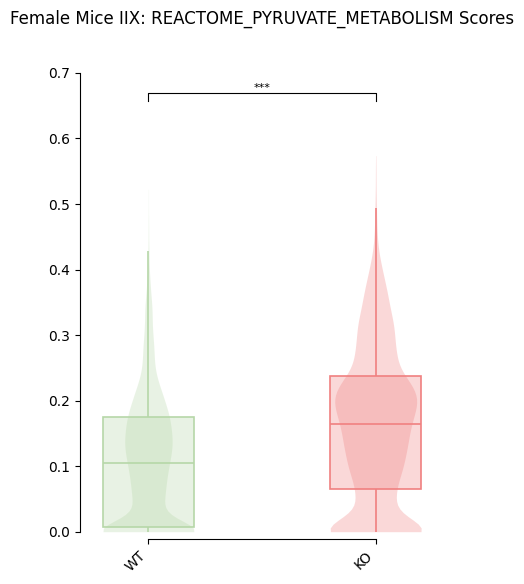

<Figure size 640x480 with 0 Axes>

In [12]:
# violin box plot for f fast iix

# choose order
order = ["WT", "KO"]

# palette keys must match age_label values
palette = {
    "WT": "#B6D7A8",
    "KO": "#F08080"
}

# plot violin box plot
fig_violin_box_iix = pgl.plot_violin_box_combo(plot_df_iix,
                                           x_var="condition",
                                           y_var=PATHWAY,
                                           title=f"Female Mice IIX: {PATHWAY} Scores",
                                           palette=palette,
                                           x_ticks=order,
                                           show_scatter=False)

display(fig_violin_box_iix)

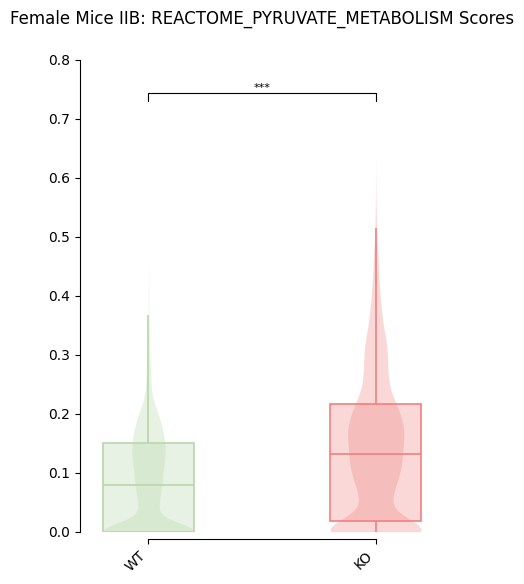

<Figure size 640x480 with 0 Axes>

In [13]:
# violin box plot for f fast iib

# choose order
order = ["WT", "KO"]

# palette keys must match age_label values
palette = {
    "WT": "#B6D7A8",
    "KO": "#F08080"
}

# plot violin box plot
fig_violin_box_iib = pgl.plot_violin_box_combo(plot_df_iib,
                                           x_var="condition",
                                           y_var=PATHWAY,
                                           title=f"Female Mice IIB: {PATHWAY} Scores",
                                           palette=palette,
                                           x_ticks=order,
                                           show_scatter=False)

display(fig_violin_box_iib)

# Gene Contribution Heatmap

,gene,spearman_corr,rank
0,Me3,0.669702,1
1,Pdk4,0.522452,2
2,Pcx,0.109906,3
3,Ldhb,0.098427,4


,gene,spearman_corr,rank
0,Pdk4,0.764616,1
1,Me3,0.510971,2
2,Pcx,0.146640,3
3,Ldhb,0.121134,4


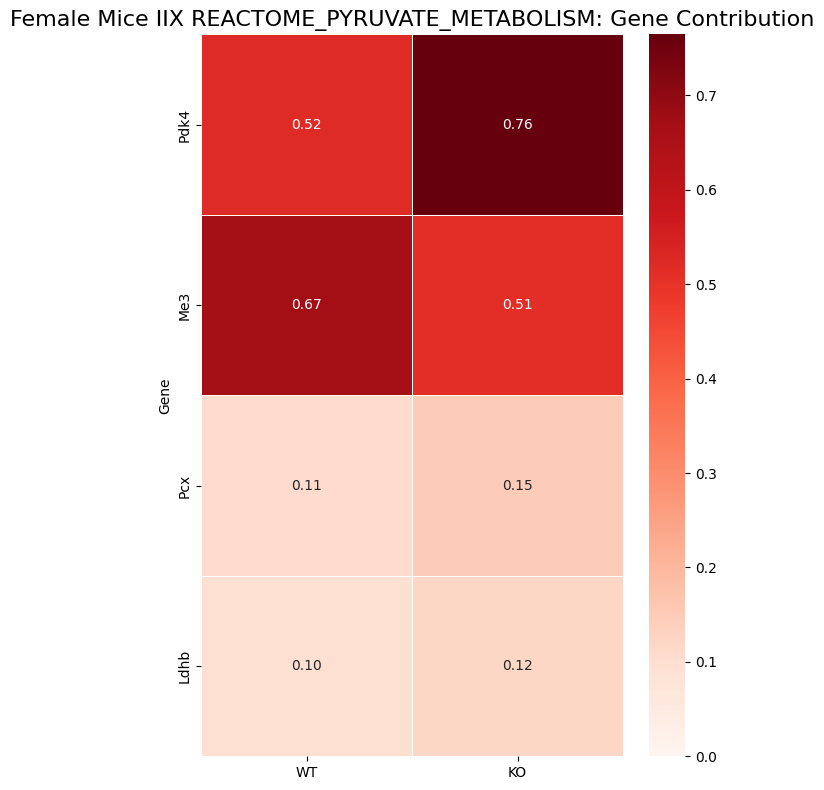

In [14]:
# gene contribution heatmap for f fast iix

# subset wt and get gene correlation
adata_iix_wt = pgl.subset_adata_by_obs(adata_mice_f_iix, filters={"condition": "WT"})
ranked_genes_iix_wt = pgl.compute_gene_correlation_against_score(adata_iix_wt, 
                                                              pgl.get_pathway_genes(geneset, PATHWAY), 
                                                              score=PATHWAY)
display(ranked_genes_iix_wt.head())

# subset wt and get gene correlation
adata_iix_ko = pgl.subset_adata_by_obs(adata_mice_f_iix, filters={"condition": "KO"})
ranked_genes_iix_ko = pgl.compute_gene_correlation_against_score(adata_iix_ko, 
                                                              pgl.get_pathway_genes(geneset, PATHWAY), 
                                                              score=PATHWAY)
display(ranked_genes_iix_ko.head())


# plot gene contribution heatmap
gene_contribution_df_iix, fig_gene_contribution_heatmap_iix, ax_gene_contribution_iix = pgl.plot_gene_contribution_heatmap(
    {"WT": ranked_genes_iix_wt,
     "KO": ranked_genes_iix_ko},
     title=f"Female Mice IIX {PATHWAY}: Gene Contribution"
)

,gene,spearman_corr,rank
0,Me3,0.815324,1
1,Pcx,0.264200,2
2,Pdk4,0.242869,3
3,Ldhb,0.028180,4


,gene,spearman_corr,rank
0,Pdk4,0.617905,1
1,Me3,0.612420,2
2,Pcx,0.473717,3
3,Ldhb,0.011300,4


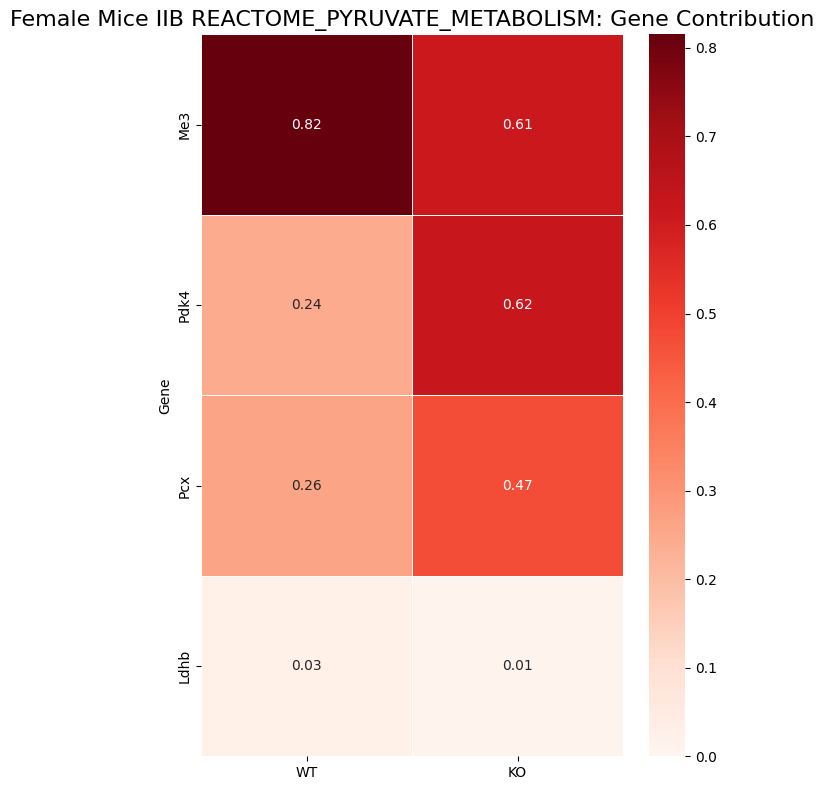

In [15]:
# gene contribution heatmap for f fast iib

# subset wt and get gene correlation
adata_iib_wt = pgl.subset_adata_by_obs(adata_mice_f_iib, filters={"condition": "WT"})
ranked_genes_iib_wt = pgl.compute_gene_correlation_against_score(adata_iib_wt, 
                                                              pgl.get_pathway_genes(geneset, PATHWAY), 
                                                              score=PATHWAY)
display(ranked_genes_iib_wt.head())

# subset wt and get gene correlation
adata_iib_ko = pgl.subset_adata_by_obs(adata_mice_f_iib, filters={"condition": "KO"})
ranked_genes_iib_ko = pgl.compute_gene_correlation_against_score(adata_iib_ko, 
                                                              pgl.get_pathway_genes(geneset, PATHWAY), 
                                                              score=PATHWAY)
display(ranked_genes_iib_ko.head())


# plot gene contribution heatmap
gene_contribution_df_iib, fig_gene_contribution_heatmap_iib, ax_gene_contribution_iib = pgl.plot_gene_contribution_heatmap(
    {"WT": ranked_genes_iib_wt,
     "KO": ranked_genes_iib_ko},
     title=f"Female Mice IIB {PATHWAY}: Gene Contribution"
)

# Cliffs Delta

In [16]:
# calculate cliffs delta for fast iix and fast iib

# store results
cliffs_results = []

# fast iix
result_df_iix, group_score_df_iix = pgl.calculate_score_cliffs_delta(
    adata=adata_mice_f_iix,
    score_col=PATHWAY,
    group_col="condition",
    group1="WT",
    group2="KO"
)

result_df_iix.insert(0, "cell_type", "Fast IIX")
result_df_iix.insert(1, "comparison", "WT_vs_KO")

cliffs_results.append(result_df_iix)


# fast iib
result_df_iib, group_score_df_iib = pgl.calculate_score_cliffs_delta(
    adata=adata_mice_f_iib,
    score_col=PATHWAY,
    group_col="condition",
    group1="WT",
    group2="KO"
)

result_df_iib.insert(0, "cell_type", "Fast IIB")
result_df_iib.insert(1, "comparison", "WT_vs_KO")

cliffs_results.append(result_df_iib)


# combine results
cliffs_celltype_df = pd.concat(cliffs_results, ignore_index=True)

display(cliffs_celltype_df)

,cell_type,comparison,score_col,WT_count,KO_count,WT_mean,KO_mean,WT_median,KO_median,WT_std,KO_std,WT_min,KO_min,WT_max,KO_max,mean_difference,median_difference,cliffs_delta,abs_cliffs_delta,higher_group
0,Fast IIX,WT_vs_KO,REACTOME_PYRUVATE_METABOLISM,9799,9028,0.111493,0.162490,0.104811,0.164948,0.098952,0.116646,0.0,0.0,0.522337,0.573883,-0.050996,-0.060137,-0.258476,0.258476,KO
1,Fast IIB,WT_vs_KO,REACTOME_PYRUVATE_METABOLISM,7570,7359,0.087095,0.142746,0.078397,0.132404,0.085606,0.123159,0.0,0.0,0.554007,0.637631,-0.055651,-0.054007,-0.253760,0.253760,KO


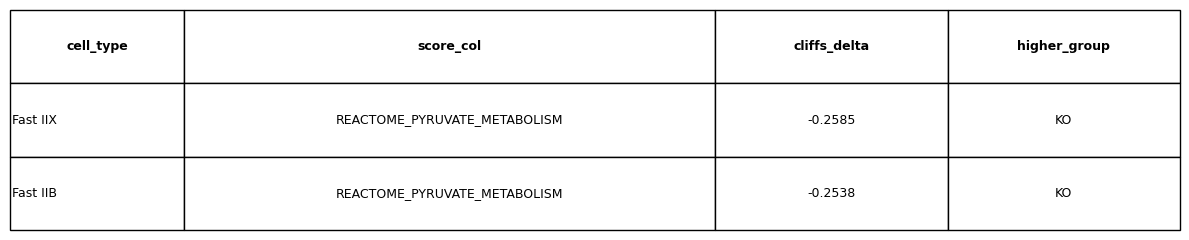

In [17]:
cliffs_delta_df = cliffs_celltype_df[["cell_type", "score_col", "cliffs_delta", "higher_group"]]

# create cliffs delta table figure
fig_cliffs_delta_table = pgl.save_df_table_image(
    df=cliffs_delta_df,
    output_path=None,
    index=False,
    round_digits=4,
    font_size=9,
    row_height=0.45
)

# Save Output

In [18]:
# save output

from pathlib import Path

# create output folder
output_dir = Path(f"Output/F_Mice_IIX_IIB_Sep/{PATHWAY}")
output_dir.mkdir(parents=True, exist_ok=True)

# file prefix
file_prefix = f"F_Mice_{PATHWAY}"


# save violin box plots

iix_violin_box_png_path = output_dir / f"{file_prefix}_FastIIX_Violin_Box_PNG.png"
iix_violin_box_svg_path = output_dir / f"{file_prefix}_FastIIX_Violin_Box_SVG.svg"

iib_violin_box_png_path = output_dir / f"{file_prefix}_FastIIB_Violin_Box_PNG.png"
iib_violin_box_svg_path = output_dir / f"{file_prefix}_FastIIB_Violin_Box_SVG.svg"

pgl.save_fig_as_png(fig_violin_box_iix, iix_violin_box_png_path)
pgl.save_editable_svg(fig_violin_box_iix, iix_violin_box_svg_path)

pgl.save_fig_as_png(fig_violin_box_iib, iib_violin_box_png_path)
pgl.save_editable_svg(fig_violin_box_iib, iib_violin_box_svg_path)


# save gene contribution heatmaps

iix_gene_contribution_png_path = output_dir / f"{file_prefix}_FastIIX_Gene_Contribution_PNG.png"
iix_gene_contribution_svg_path = output_dir / f"{file_prefix}_FastIIX_Gene_Contribution_SVG.svg"

iib_gene_contribution_png_path = output_dir / f"{file_prefix}_FastIIB_Gene_Contribution_PNG.png"
iib_gene_contribution_svg_path = output_dir / f"{file_prefix}_FastIIB_Gene_Contribution_SVG.svg"

cliffs_delta_png_path = output_dir / f"{file_prefix}_Cliffs_Delta_Table_PNG.png"
cliffs_delta_svg_path = output_dir / f"{file_prefix}_Cliffs_Delta_Table_SVG.svg"


pgl.save_fig_as_png(fig_gene_contribution_heatmap_iix, iix_gene_contribution_png_path)
pgl.save_editable_svg(fig_gene_contribution_heatmap_iix, iix_gene_contribution_svg_path)

pgl.save_fig_as_png(fig_gene_contribution_heatmap_iib, iib_gene_contribution_png_path)
pgl.save_editable_svg(fig_gene_contribution_heatmap_iib, iib_gene_contribution_svg_path)

pgl.save_fig_as_png(
    fig=fig_cliffs_delta_table,
    output_path=cliffs_delta_png_path
)

pgl.save_editable_svg(
    fig=fig_cliffs_delta_table,
    output_path=cliffs_delta_svg_path
)

# print saved paths

print(f"saved: {iix_violin_box_png_path}")
print(f"saved: {iix_violin_box_svg_path}")

print(f"saved: {iib_violin_box_png_path}")
print(f"saved: {iib_violin_box_svg_path}")

print(f"saved: {iix_gene_contribution_png_path}")
print(f"saved: {iix_gene_contribution_svg_path}")

print(f"saved: {iib_gene_contribution_png_path}")
print(f"saved: {iib_gene_contribution_svg_path}")

print(f"saved: {cliffs_delta_png_path}")
print(f"saved: {cliffs_delta_svg_path}")

saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastIIX_Violin_Box_PNG.png
saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastIIX_Violin_Box_SVG.svg
saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastIIB_Violin_Box_PNG.png
saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastIIB_Violin_Box_SVG.svg
saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastIIX_Gene_Contribution_PNG.png
saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastIIX_Gene_Contribution_SVG.svg
saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastIIB_Gene_Contribution_PNG.png
saved: Output/F_Mice_IIX_IIB_Sep/REACTOME_PYRUVATE_METABOLISM/F_Mice_REACTOME_PYRUVATE_METABOLISM_FastII